In [ ]:
import os
import time
import math
import pickle
from contextlib import nullcontext

import numpy as np
import torch
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group

from model import (
    GPTConfig,
    GPT,
    CausalSelfAttention,
    SplitCausalSelfAttentionVariableNumHeadsIndependent,
)

from matplotlib import pyplot as plt
from typing import Optional
from tqdm import tqdm
import torch.nn.functional as F

from attention_head_similarity import (
    compute_pairwise_symmetric_similarity_matrix,
    compute_aggr_pairwise_similarity,
    cka,
    cosine_similarity,
    compute_aggr_pairwise_similarity,
    compute_mean_per_head_similarities,
)

In [2]:
device_type = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(device_type)
dtype = "bfloat16"
dataset = "openwebtext"

In [3]:
batch_size = 16
checkpoints_dir = "out-16m-compute-optimal"

In [22]:
def load_checkpoint(
    checkpoint_base_dir: str, checkpoint_iter: int, output_attentions: bool = False
):
    model_args = {}
    ckpt_path = os.path.join(checkpoint_base_dir, f"ckpt_{checkpoint_iter}.pt")
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    checkpoint_model_args = checkpoint["model_args"]
    # force these config attributes to be equal otherwise we can't even resume training
    # the rest of the attributes (e.g. dropout) can stay as desired from command line
    for k in ["n_layer", "n_head", "n_embd", "block_size", "bias", "vocab_size"]:
        model_args[k] = checkpoint_model_args[k]
    # create the model
    gptconf = GPTConfig(**model_args)
    gptconf.output_attentions = output_attentions  # update config if needed
    model = GPT(gptconf)
    state_dict = checkpoint["model"]
    # fix the keys of the state dictionary :(
    # honestly no idea how checkpoints sometimes get this prefix, have to debug more
    unwanted_prefix = "_orig_mod."
    for k, v in list(state_dict.items()):
        if k.startswith(unwanted_prefix):
            state_dict[k[len(unwanted_prefix) :]] = state_dict.pop(k)
    model.load_state_dict(state_dict, strict=False)
    return model, gptconf

In [5]:
ptdtype = {
    "float32": torch.float32,
    "bfloat16": torch.bfloat16,
    "float16": torch.float16,
}[dtype]
ctx = (
    nullcontext()
    if device_type == "cpu"
    else torch.amp.autocast(device_type=device_type, dtype=ptdtype)
)

# poor man's data loader
data_dir = os.path.join("data", dataset)


def get_batch(split, batch_size, block_size):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == "train":
        data = np.memmap(os.path.join(data_dir, "train.bin"), dtype=np.uint16, mode="r")
    else:
        data = np.memmap(os.path.join(data_dir, "val.bin"), dtype=np.uint16, mode="r")
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack(
        [torch.from_numpy((data[i : i + block_size]).astype(np.int64)) for i in ix]
    )
    y = torch.stack(
        [
            torch.from_numpy((data[i + 1 : i + 1 + block_size]).astype(np.int64))
            for i in ix
        ]
    )
    if device_type == "cuda":
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(
            device, non_blocking=True
        )
    else:
        x, y = x.to(device), y.to(device)
    return x, y

In [6]:
early_model, model_cfg = load_checkpoint(100, True)
late_model, _ = load_checkpoint(3900, True)
mid_model, _ = load_checkpoint(1000, True)

number of parameters: 16.03M
number of parameters: 16.03M
number of parameters: 16.03M


In [7]:
# helps estimate an arbitrarily accurate loss over either split using many batches
@torch.no_grad()
def estimate_loss(model, eval_iters: int = 100):
    out = {}
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split, batch_size, model_cfg.block_size)
            with ctx:
                if model_cfg.output_attentions:
                    logits, loss, attn_weights = model(X, Y)
                else:
                    logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [8]:
estimate_loss(early_model, 10)

ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
estimate_loss(mid_model, 10)

{'train': tensor(4.8360), 'val': tensor(4.8870)}

In [ ]:
estimate_loss(late_model, 10)

{'train': tensor(4.1089), 'val': tensor(4.1411)}

In [7]:
X, Y = get_batch("val", 16, model_cfg.block_size)
with ctx:
    attn_weights_list = []
    for model in [early_model, mid_model, late_model]:
        _, _, attn_weights = model(X, Y, output_attentions=True)
        attn_weights_list.append(attn_weights)

In [11]:
attn_weights[0].shape

torch.Size([16, 4, 512, 512])

In [12]:
def show_attn(
    attn_map: np.ndarray,
    token_labels: Optional[list[str]] = None,
    log_scale: bool = False,
) -> None:
    """
    Visualizes an attention map with token labels.

    Parameters:
        attn_map (np.ndarray): The attention map to visualize. It is expected to be a 2D array.
        token_labels (list[str]): A list of token labels corresponding to the attention map.
        log_scale (bool, optional): If True, applies a logarithmic scale to the attention map values. Defaults to False.

    Returns:
        None
    """
    _, ax = plt.subplots(figsize=(8, 8))

    # mask for plotting the bad color for padding tokens (upper triangular part)
    attn_map = np.ma.masked_where(attn_map == 0, attn_map)

    cmap = plt.cm.coolwarm
    cmap.set_bad(color="grey")
    ax.matshow(np.log(attn_map) if log_scale else attn_map, cmap=cmap)

    ax.xaxis.set_label_position("bottom")  # Move x-axis label to the bottom
    ax.xaxis.tick_bottom()  # Ensure ticks are on the bottom
    if token_labels is not None:
        _ = ax.set_xticks(
            range(len(token_labels)),
            token_labels,
            fontsize=9,
            rotation=90,
        )
        _ = ax.set_yticks(
            range(len(token_labels)),
            token_labels,
            fontsize=9,
        )
    ax.set_ylabel("Query token", fontsize=12)
    ax.set_xlabel("Key token", fontsize=12)

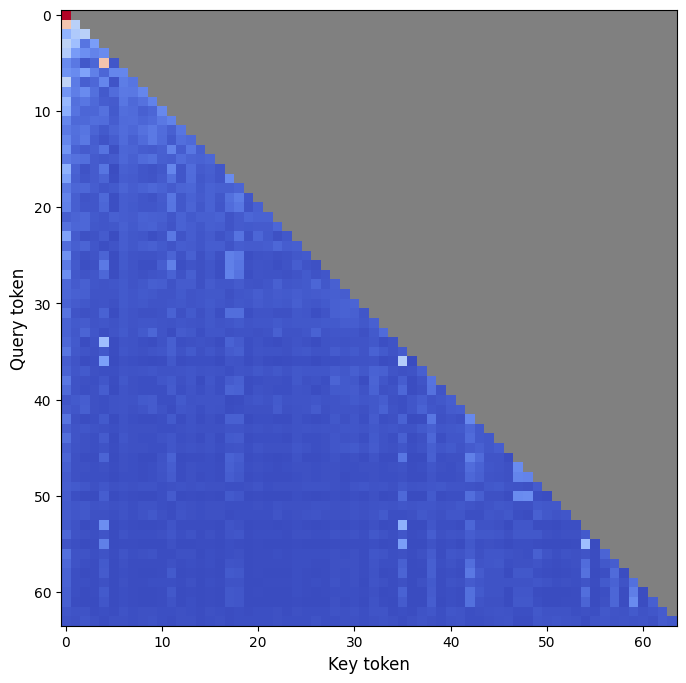

In [18]:
show_attn(attn_weights_list[2][0][0, 1, :64, :64])

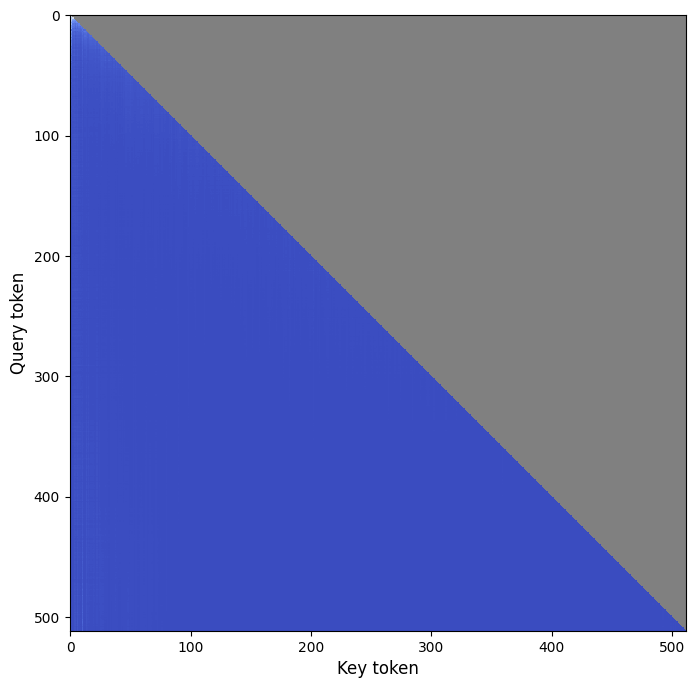

In [31]:
show_attn(attn_weights_list[2][0][0, 0, :, :])

In [93]:
# early model.
attn_weights_list[0][0][0, 0, :4, :4]

tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.4351, 0.5649, 0.0000, 0.0000],
        [0.2747, 0.3368, 0.3885, 0.0000],
        [0.1842, 0.2439, 0.3251, 0.2468]])

In [8]:
attn_map1 = attn_weights_list[1][2][0, 0]
attn_map2 = attn_weights_list[1][2][0, 2]

In [135]:
m = torch.tril(torch.ones(512, 512))

In [125]:
attn_map[m.bool()]

tensor([1.0000, 0.4351, 0.5649, 0.2747, 0.3368, 0.3885, 0.1842, 0.2439, 0.3251,
        0.2468])

In [129]:
attn_map @ attn_map.T

tensor([[1.0000, 0.4351, 0.2747, 0.1842],
        [0.4351, 0.5084, 0.3098, 0.2179],
        [0.2747, 0.3098, 0.3398, 0.2591],
        [0.1842, 0.2179, 0.2591, 0.2600]])

In [129]:
attn1 = torch.ones(16, 512, 512) + torch.randn(16, 512, 512) / 1
attn2 = torch.ones(16, 512, 512)

In [130]:
def cosine_similarity(attn1, attn2):
    attn1 = attn1.reshape(attn1.shape[0], -1)
    attn2 = attn2.reshape(attn2.shape[0], -1)

    return F.cosine_similarity(attn1, attn2).mean().item()

In [131]:
cosine_similarity(attn1, attn2)

0.7069788575172424

In [124]:
def biased_hsic(gram1, gram2):
    """
    Computes the Hilbert-Schmidt Independence Criterion (HSIC) between two attention maps.
    """

    h = (
        torch.eye(gram1.shape[0])
        - torch.ones(gram1.shape[0], gram1.shape[0]) / gram1.shape[0]
    )  # centering matrix

    # compute the HSIC value
    hsic_value = torch.trace(gram1 @ h @ gram2 @ h) / ((gram1.shape[0] - 1) ** 2)
    return hsic_value


def unbiased_hsic(gram1, gram2):
    gram1_copy = gram1.clone()
    gram2_copy = gram2.clone()

    gram1_copy.fill_diagonal_(0)  # zero out the diagonal
    gram2_copy.fill_diagonal_(0)  # zero out the diagonal
    n = gram1_copy.shape[0]

    first_term = torch.trace(gram1_copy @ gram2_copy)
    second_term = (gram1_copy.sum() * gram2_copy.sum()) / ((n - 1) * (n - 2))
    third_term = (gram1_copy @ gram2_copy).sum() * 2 / (n - 2)

    return (first_term + second_term - third_term) / (n * (n - 3))


def cka(
    attn1: torch.Tensor | list[torch.Tensor],
    attn2: torch.Tensor | list[torch.Tensor],
    hsic_fn: callable = unbiased_hsic,
):
    """
    Computes the Centered Kernel Alignment (CKA) between two attention maps.
    """
    if len(attn1.shape) == 2:
        attn1 = [attn1]
        attn2 = [attn2]
    else:
        assert len(attn1) == len(
            attn2
        ), "Both attention map lists/tensors must have the same length."

    hsic_kl = hsic_kk = hsic_ll = 0
    for a1, a2 in zip(attn1, attn2):
        gram1 = a1 @ a1.T  # compute the Gram matrix
        gram2 = a2 @ a2.T  # compute the Gram matrix

        hsic_kl += hsic_fn(gram1, gram2) / len(attn1)
        hsic_kk += hsic_fn(gram1, gram1) / len(attn1)
        hsic_ll += hsic_fn(gram2, gram2) / len(attn1)

    return (hsic_kl / torch.sqrt(hsic_kk * hsic_ll)).item()

In [61]:
cka(attn_map1, attn_map2, unbiased_hsic)

0.6538535952568054

In [62]:
cka(attn_map1, attn_map2, biased_hsic)

0.7366141080856323

In [13]:
def test_hsic_implementations(n=100):
    # Create perfectly correlated data
    x = torch.randn(n, 10)
    y = x.clone()  # Perfect correlation

    # Create kernel matrices
    gram_x = x @ x.T
    gram_y = y @ y.T

    biased_c = biased_hsic(gram_x, gram_y)
    unbiased_c = unbiased_hsic(gram_x, gram_y)

    # Create uncorrelated data
    z = torch.randn(n, 10)
    gram_z = z @ z.T

    biased_uc = biased_hsic(gram_x, gram_z)
    unbiased_uc = unbiased_hsic(gram_x, gram_z)

    return biased_c, unbiased_c, biased_uc, unbiased_uc


test_hsic_implementations()

(tensor(13.9165), tensor(12.5522), tensor(1.0371), tensor(-0.0060))

In [17]:
n = torch.linspace(10, 10**4, 20, dtype=torch.int32)
hsic_biased_c = []
hsic_unbiased_c = []
hsic_biased_uc = []
hsic_unbiased_uc = []
for i in tqdm(n):
    biased_c, unbiased_c, biased_uc, unbiased_uc = test_hsic_implementations(i)
    hsic_biased_c.append(biased_c)
    hsic_unbiased_c.append(unbiased_c)
    hsic_biased_uc.append(biased_uc)
    hsic_unbiased_uc.append(unbiased_uc)

100%|██████████| 20/20 [01:05<00:00,  3.29s/it]


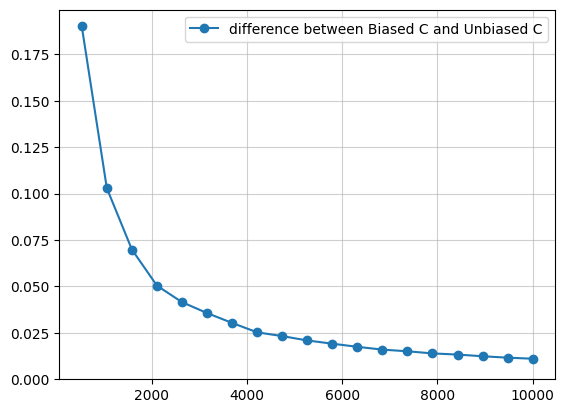

In [35]:
plt.plot(
    n[1:],
    [x - y for (x, y) in zip(hsic_biased_c[1:], hsic_unbiased_c[1:])],
    label="difference between Biased C and Unbiased C",
    marker="o",
)
# plt.plot(n[2:], hsic_unbiased_c[2:], label="Unbiased C", marker="o")
plt.grid(alpha=0.6)
plt.legend()
plt.ylim(0)
plt.show()

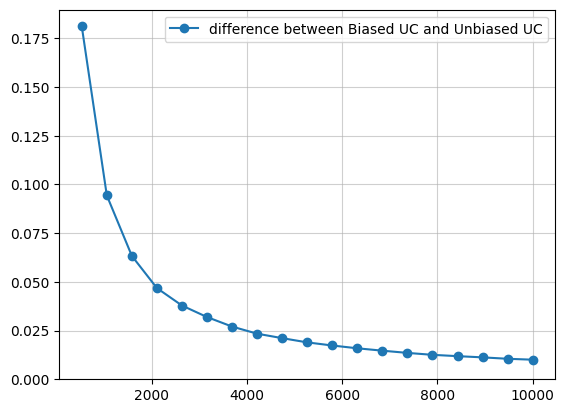

In [34]:
plt.plot(
    n[1:],
    [x - y for (x, y) in zip(hsic_biased_uc[1:], hsic_unbiased_uc[1:])],
    label="difference between Biased UC and Unbiased UC",
    marker="o",
)
plt.grid(alpha=0.6)
plt.legend()
plt.ylim(0)
plt.show()

In [36]:
def test_cka_implementations(n=100, d=10):
    # Create perfectly correlated matrices
    x = torch.randn(n, d)
    y = x.clone()  # Perfect correlation

    # Create partially correlated matrices
    correlation = 0.5
    y_partial = x * correlation + torch.randn(n, d) * (1 - correlation)

    # Create uncorrelated matrices
    z = torch.randn(n, d)

    # Calculate CKA for each correlation level with both HSIC implementations
    results = {}

    # Perfect correlation
    results["perfect_biased"] = cka(x, y, biased_hsic)
    results["perfect_unbiased"] = cka(x, y, unbiased_hsic)

    # Partial correlation
    results["partial_biased"] = cka(x, y_partial, biased_hsic)
    results["partial_unbiased"] = cka(x, y_partial, unbiased_hsic)

    # No correlation
    results["uncorr_biased"] = cka(x, z, biased_hsic)
    results["uncorr_unbiased"] = cka(x, z, unbiased_hsic)

    return results


# Test CKA with different data sizes
n_values = torch.linspace(10, 10**4, 20, dtype=torch.int32)
results = {
    "perfect_biased": [],
    "perfect_unbiased": [],
    "partial_biased": [],
    "partial_unbiased": [],
    "uncorr_biased": [],
    "uncorr_unbiased": [],
}

for n in tqdm(n_values):
    test_results = test_cka_implementations(n=n)
    for key in results.keys():
        results[key].append(test_results[key])

100%|██████████| 20/20 [04:29<00:00, 13.46s/it]


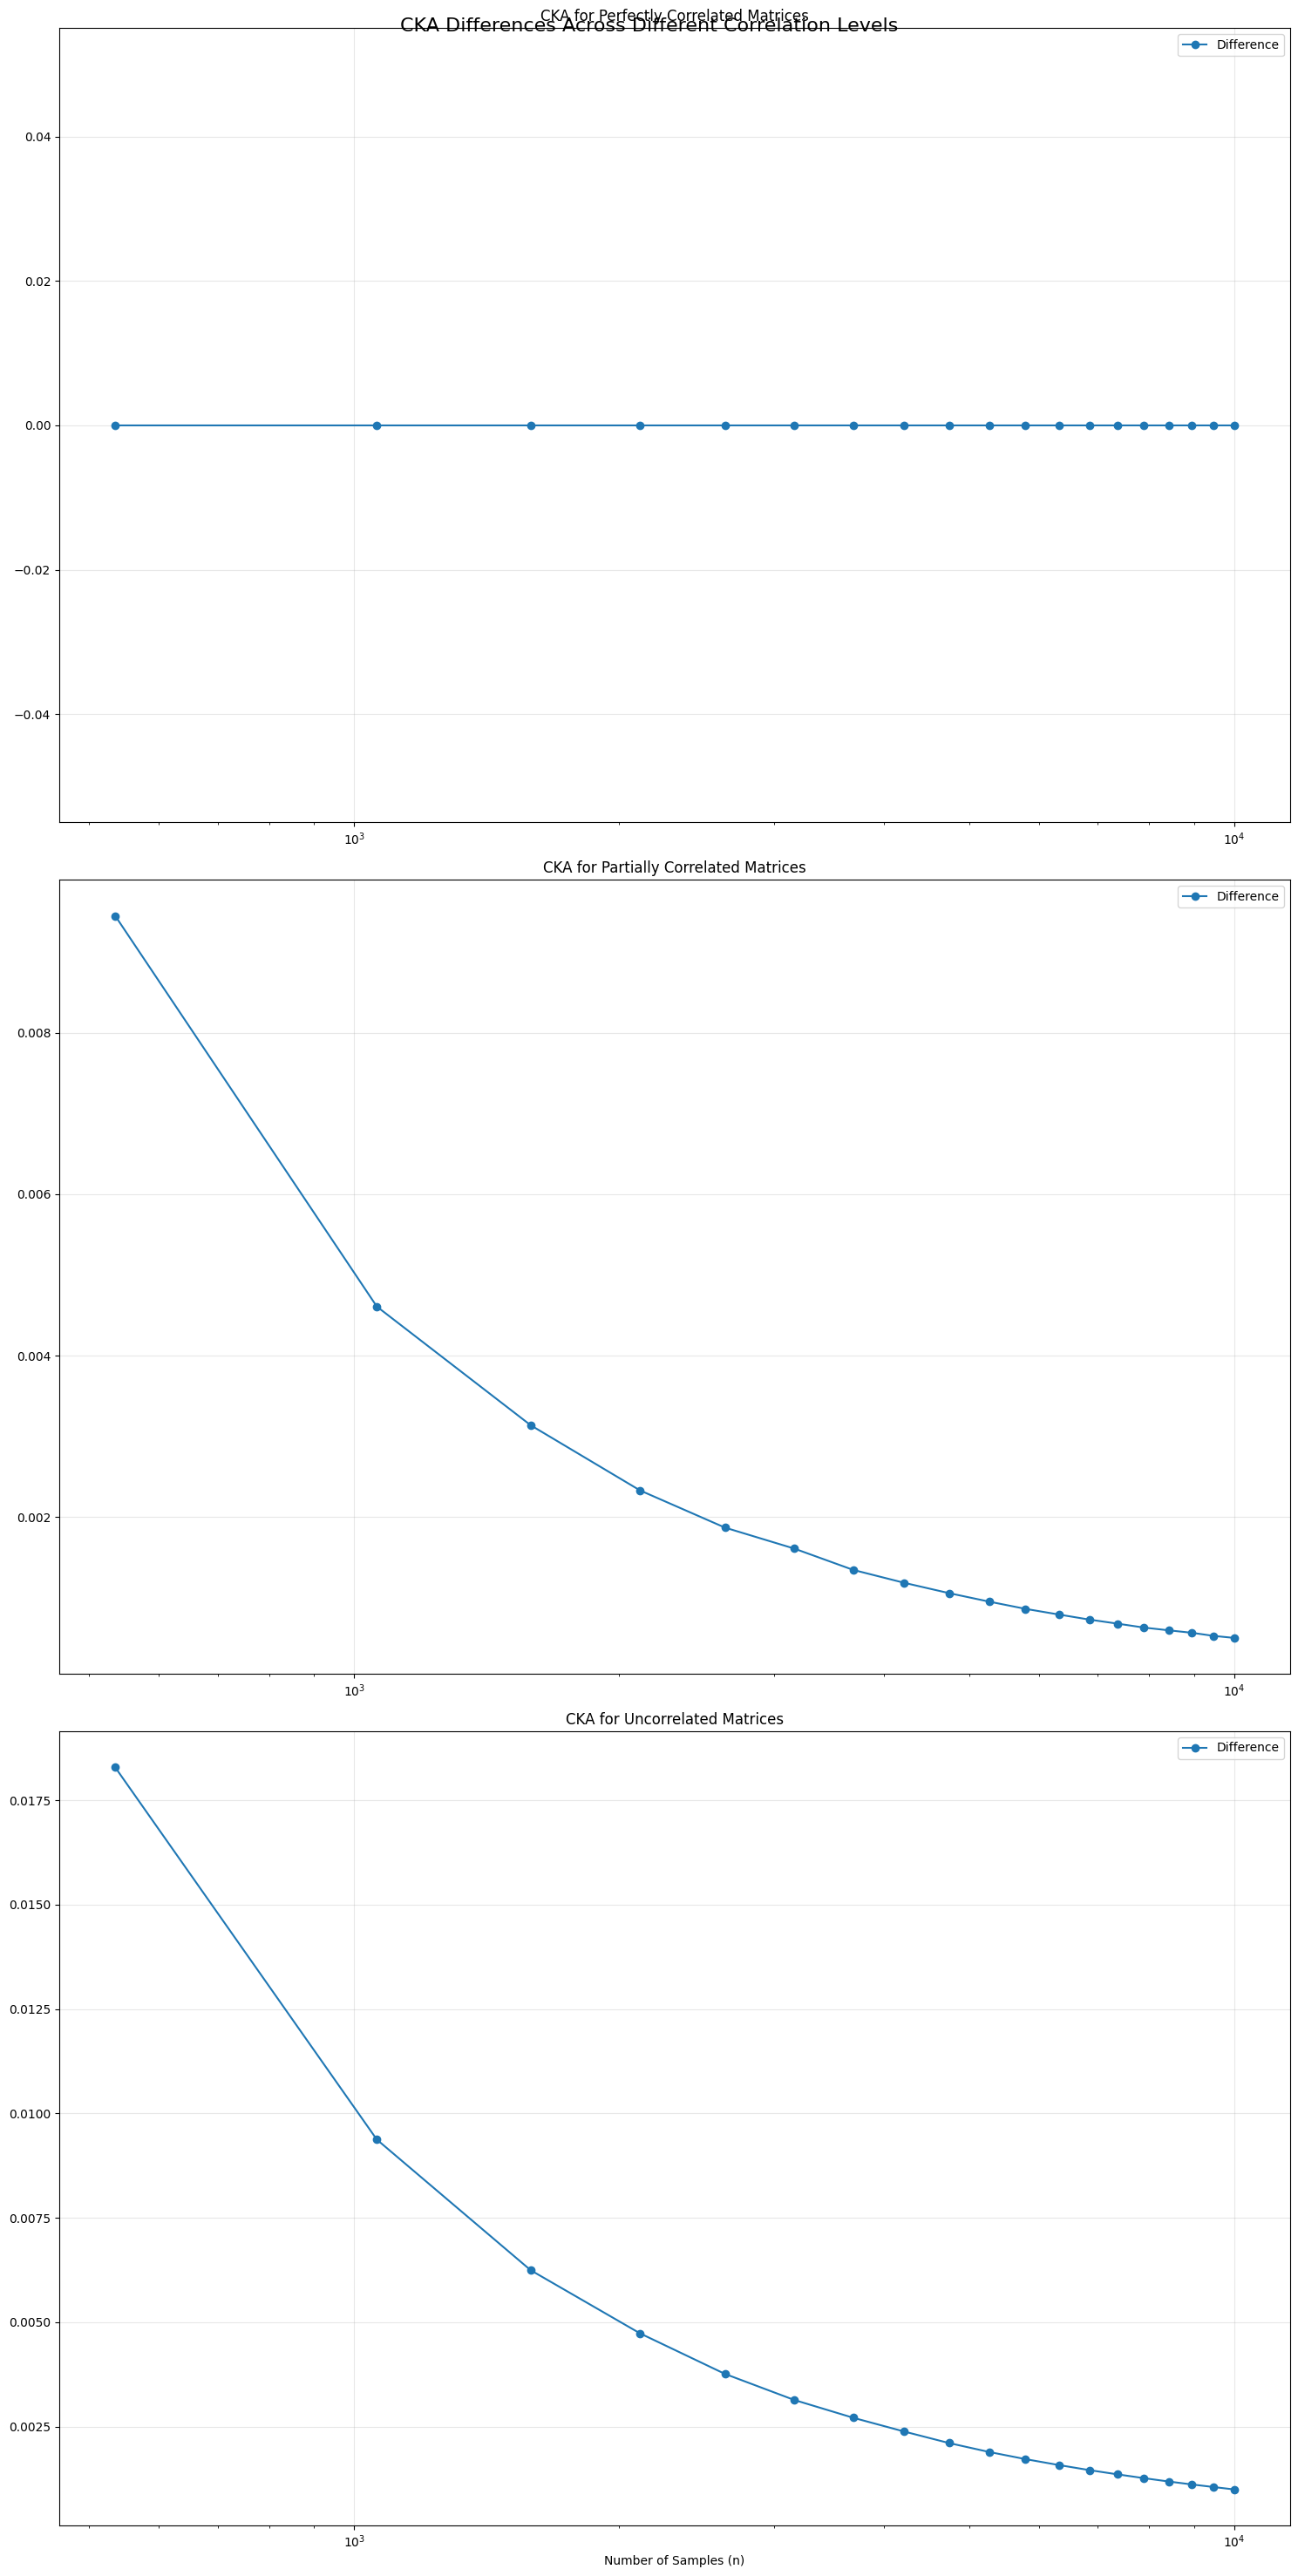

In [37]:
# Plot results
plt.figure(figsize=(15, 30))

# Perfect correlation
plt.subplot(3, 1, 1)
plt.plot(
    n_values[1:],
    torch.tensor(results["perfect_biased"][1:])
    - torch.tensor(results["perfect_unbiased"][1:]),
    label="Difference",
    marker="o",
)
plt.xscale("log")
plt.title("CKA for Perfectly Correlated Matrices")
plt.grid(alpha=0.3)
plt.legend()

# Partial correlation
plt.subplot(3, 1, 2)
plt.plot(
    n_values[1:],
    torch.tensor(results["partial_biased"][1:])
    - torch.tensor(results["partial_unbiased"][1:]),
    label="Difference",
    marker="o",
)
plt.xscale("log")
plt.title("CKA for Partially Correlated Matrices")
plt.grid(alpha=0.3)
plt.legend()

# Uncorrelated matrices
plt.subplot(3, 1, 3)
plt.plot(
    n_values[1:],
    torch.tensor(results["uncorr_biased"][1:])
    - torch.tensor(results["uncorr_unbiased"][1:]),
    label="Difference",
    marker="o",
)
plt.xscale("log")
plt.title("CKA for Uncorrelated Matrices")
plt.grid(alpha=0.3)
plt.xlabel("Number of Samples (n)")
plt.legend()
plt.suptitle("CKA Differences Across Different Correlation Levels", fontsize=16)

plt.tight_layout()
plt.show()

In [136]:
def aggregate_head_pairwise_metric_batch(
    attn_weights: torch.Tensor,
    metric_fn: callable,
    aggregate_fn: Optional[callable] = None,
) -> float:
    """
    Computes a pairwise metric (e.g., CKA, HSIC) for all head pairs in the attention weights.

    Parameters:
        attn_weights (torch.Tensor): Attention weights of shape (batch_size, n_heads, seq_len, seq_len).
        metric_fn (callable): Function to compute the pairwise metric.
        aggregate_fn (callable, optional): Function to aggregate the results across head pairs. If not provided, return the metric results.

    Returns:
        float: The aggregated metric value.
    """
    n_heads = attn_weights.shape[1]
    metrics = []

    for i in range(n_heads):
        for j in range(i + 1, n_heads):
            metric_value = metric_fn(attn_weights[:, i], attn_weights[:, j])
            metrics.append(metric_value)

    if aggregate_fn is None:
        return metrics
    else:
        return aggregate_fn(torch.tensor(metrics)).item()

In [64]:
aggregate_head_pairwise_metric_batch(attn_weights_list[1][0], cka)

0.8323466777801514

In [67]:
aggregate_head_pairwise_metric_batch(attn_weights_list[2][0], cka)

0.7248745560646057

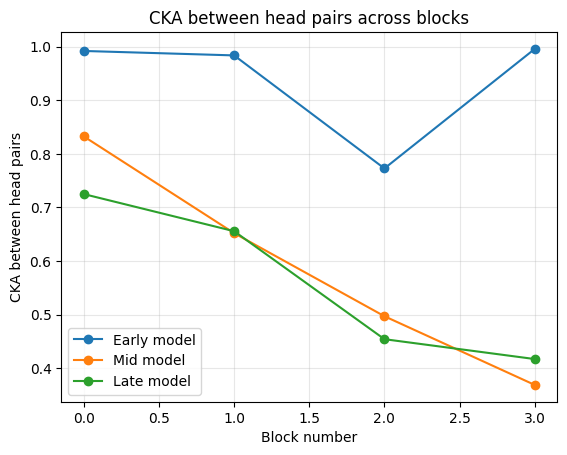

In [68]:
n_blocks = 4
plt.plot(
    range(n_blocks),
    [
        aggregate_head_pairwise_metric_batch(attn_weights_list[0][b], cka)
        for b in range(n_blocks)
    ],
    label="Early model",
    marker="o",
)
plt.plot(
    range(n_blocks),
    [
        aggregate_head_pairwise_metric_batch(attn_weights_list[1][b], cka)
        for b in range(n_blocks)
    ],
    label="Mid model",
    marker="o",
)
plt.plot(
    range(n_blocks),
    [
        aggregate_head_pairwise_metric_batch(attn_weights_list[2][b], cka)
        for b in range(n_blocks)
    ],
    label="Late model",
    marker="o",
)

plt.xlabel("Block number")
plt.ylabel("CKA between head pairs")
plt.title("CKA between head pairs across blocks")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [165]:
eval_iters = 10  # number of batches to use for evaluation
checkpoint_nums = range(0, 4100, 100)

n_blocks = 4  # number of blocks in the model
cka_results = []
cka_results_std = []

for i in tqdm(checkpoint_nums):
    model, _ = load_checkpoint(i, True)
    per_block_results = [[] for _ in range(n_blocks)]
    for i in range(eval_iters):
        X, Y = get_batch("val", batch_size, model_cfg.block_size)
        attn_weights = model(X, Y)[2]
        for b in range(n_blocks):
            per_block_results[b].extend(
                aggregate_head_pairwise_metric_batch(
                    attn_weights[b],
                    cosine_similarity,
                )
            )

    per_block_results_std = np.std(per_block_results, axis=1)
    per_block_results = np.mean(per_block_results, axis=1)
    cka_results.append(per_block_results)
    cka_results_std.append(per_block_results_std)

    del model, attn_weights

  0%|          | 0/41 [00:00<?, ?it/s]

number of parameters: 16.03M


  2%|▏         | 1/41 [00:06<04:36,  6.91s/it]

number of parameters: 16.03M


  2%|▏         | 1/41 [00:07<05:15,  7.90s/it]


KeyboardInterrupt: 

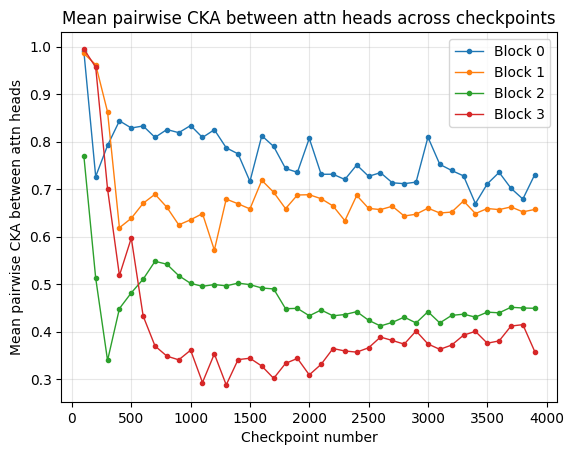

In [133]:
n_blocks = len(cka_results[0])

for block_num in range(n_blocks):
    plt.plot(
        checkpoint_nums,
        [cka_results[i][block_num] for i in range(len(cka_results))],
        label=f"Block {block_num}",
        marker="o",
        markersize=3,
        linewidth=1,
    )
plt.xlabel("Checkpoint number")
plt.ylabel("Mean pairwise CKA between attn heads")
plt.title("Mean pairwise CKA between attn heads across checkpoints")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [166]:
eval_iters = 10  # number of batches to use for evaluation
checkpoint_nums = range(0, 4100, 100)

n_blocks = 4  # number of blocks in the model
cka_results = []
cka_results_std = []

for i in tqdm(checkpoint_nums):
    model, _ = load_checkpoint(i, True)
    per_block_results = [[] for _ in range(n_blocks)]
    for i in range(eval_iters):
        X, Y = get_batch("val", batch_size, model_cfg.block_size)
        attn_weights = model(X, Y)[2]
        for b in range(n_blocks):
            per_block_results[b].extend(
                aggregate_head_pairwise_metric_batch(attn_weights[b], cka)
            )

    per_block_results_std = np.std(per_block_results, axis=1)
    per_block_results = np.mean(per_block_results, axis=1)
    cka_results.append(per_block_results)
    cka_results_std.append(per_block_results_std)

    del model, attn_weights

  0%|          | 0/41 [00:00<?, ?it/s]

number of parameters: 16.03M


  2%|▏         | 1/41 [00:14<09:49, 14.73s/it]

number of parameters: 16.03M


  5%|▍         | 2/41 [00:29<09:34, 14.74s/it]

...

 95%|█████████▌| 39/41 [09:41<00:32, 16.20s/it]

number of parameters: 16.03M


 98%|█████████▊| 40/41 [09:58<00:16, 16.32s/it]

number of parameters: 16.03M


100%|██████████| 41/41 [10:14<00:00, 14.99s/it]


In [162]:
cka_results_std[30]

array([0.09798029, 0.121119  , 0.1531609 , 0.16822223])

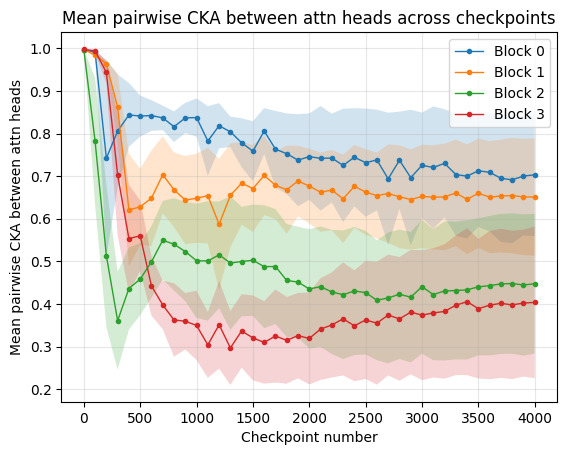

In [167]:
n_blocks = len(cka_results[0])

for block_num in range(n_blocks):
    plt.fill_between(
        checkpoint_nums,
        [
            cka_results[i][block_num] - cka_results_std[i][block_num]
            for i in range(len(cka_results))
        ],
        [
            cka_results[i][block_num] + cka_results_std[i][block_num]
            for i in range(len(cka_results))
        ],
        alpha=0.2,
    )
    plt.plot(
        checkpoint_nums,
        [cka_results[i][block_num] for i in range(len(cka_results))],
        label=f"Block {block_num}",
        marker="o",
        markersize=3,
        linewidth=1,
    )
plt.xlabel("Checkpoint number")
plt.ylabel("Mean pairwise CKA between attn heads")
plt.title("Mean pairwise CKA between attn heads across checkpoints")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [178]:
attn_weights_list[0][0].shape

torch.Size([16, 4, 512, 512])

In [8]:
S = compute_pairwise_symmetric_similarity_matrix(
    attn_weights_list[2][0],
    metric_fn=cka,
)

In [9]:
S

tensor([[1.0000, 0.7582, 0.8879, 0.5283],
        [0.7582, 1.0000, 0.8219, 0.6727],
        [0.8879, 0.8219, 1.0000, 0.5723],
        [0.5283, 0.6727, 0.5723, 1.0000]])

In [12]:
compute_aggr_pairwise_similarity(S, torch.mean)

0.6817776560783386

In [13]:
compute_aggr_pairwise_similarity(S, torch.std)

0.15688250958919525

In [ ]:
n = S.shape[0]

In [16]:
upper_tri_indices = torch.triu_indices(n, n, offset=1)
upper_tri_values = S[upper_tri_indices[0], upper_tri_indices[1]]

In [17]:
upper_tri_values.mean()

tensor(0.6818)

In [19]:
def compute_mean_per_head_similarities(
    sim_matrix: torch.Tensor,
) -> torch.Tensor:
    """
    Computes mean similarity values for a specific head across all other heads.
    Parameters:
        sim_matrix (torch.Tensor): A symmetric matrix of shape (n_heads, n_heads) containing pairwise similarity values.
    Returns:
        torch.Tensor: A tensor of shape (n_heads,) containing the similarity values for each head.
    """
    n = sim_matrix.shape[0]
    per_head_similarities = torch.zeros(n, dtype=torch.float32)
    for i in range(n):
        # subtract 1 to remove self-similarity, then divide by (n-1) to normalize
        per_head_similarities[i] = (sim_matrix[i, :].sum() - 1) / (n - 1)

    return per_head_similarities

In [22]:
S

tensor([[1.0000, 0.7582, 0.8879, 0.5283],
        [0.7582, 1.0000, 0.8219, 0.6727],
        [0.8879, 0.8219, 1.0000, 0.5723],
        [0.5283, 0.6727, 0.5723, 1.0000]])

In [21]:
compute_mean_per_head_similarities(S)

tensor([0.7248, 0.7509, 0.7607, 0.5911])

In [21]:
def log_per_head_model_heatmap(per_layer_head_similarities: list[torch.Tensor]):

    S = torch.vstack(per_layer_head_similarities[::-1])

    fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
    im = ax.imshow(S, vmin=0, vmax=1, cmap="viridis")
    ax.set_title(f"Per-Head Model CKA Similarity Heatmap")
    ax.set_xlabel("Head index")
    ax.set_ylabel("Layer index")

    # Set y-ticks to reflect the correct layer indices (reversed)
    num_layers = S.shape[0]
    ax.set_yticks(range(num_layers))
    ax.set_yticklabels(range(num_layers - 1, -1, -1))  # Reversed layer indices

    # Set x-ticks to reflect the correct head indices
    num_heads = S.shape[1]
    ax.set_xticks(range(num_heads))
    ax.set_xticklabels(range(num_heads))
    ax.tick_params(axis="both", which="major", labelsize=12)
    # Add value annotations
    for i in range(S.shape[0]):  # iterate over layers
        for j in range(S.shape[1]):
            value = S[i, j].item()
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color="white" if value < 0.5 else "black",
            )

    # Add colorbar
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()
    plt.close(fig)

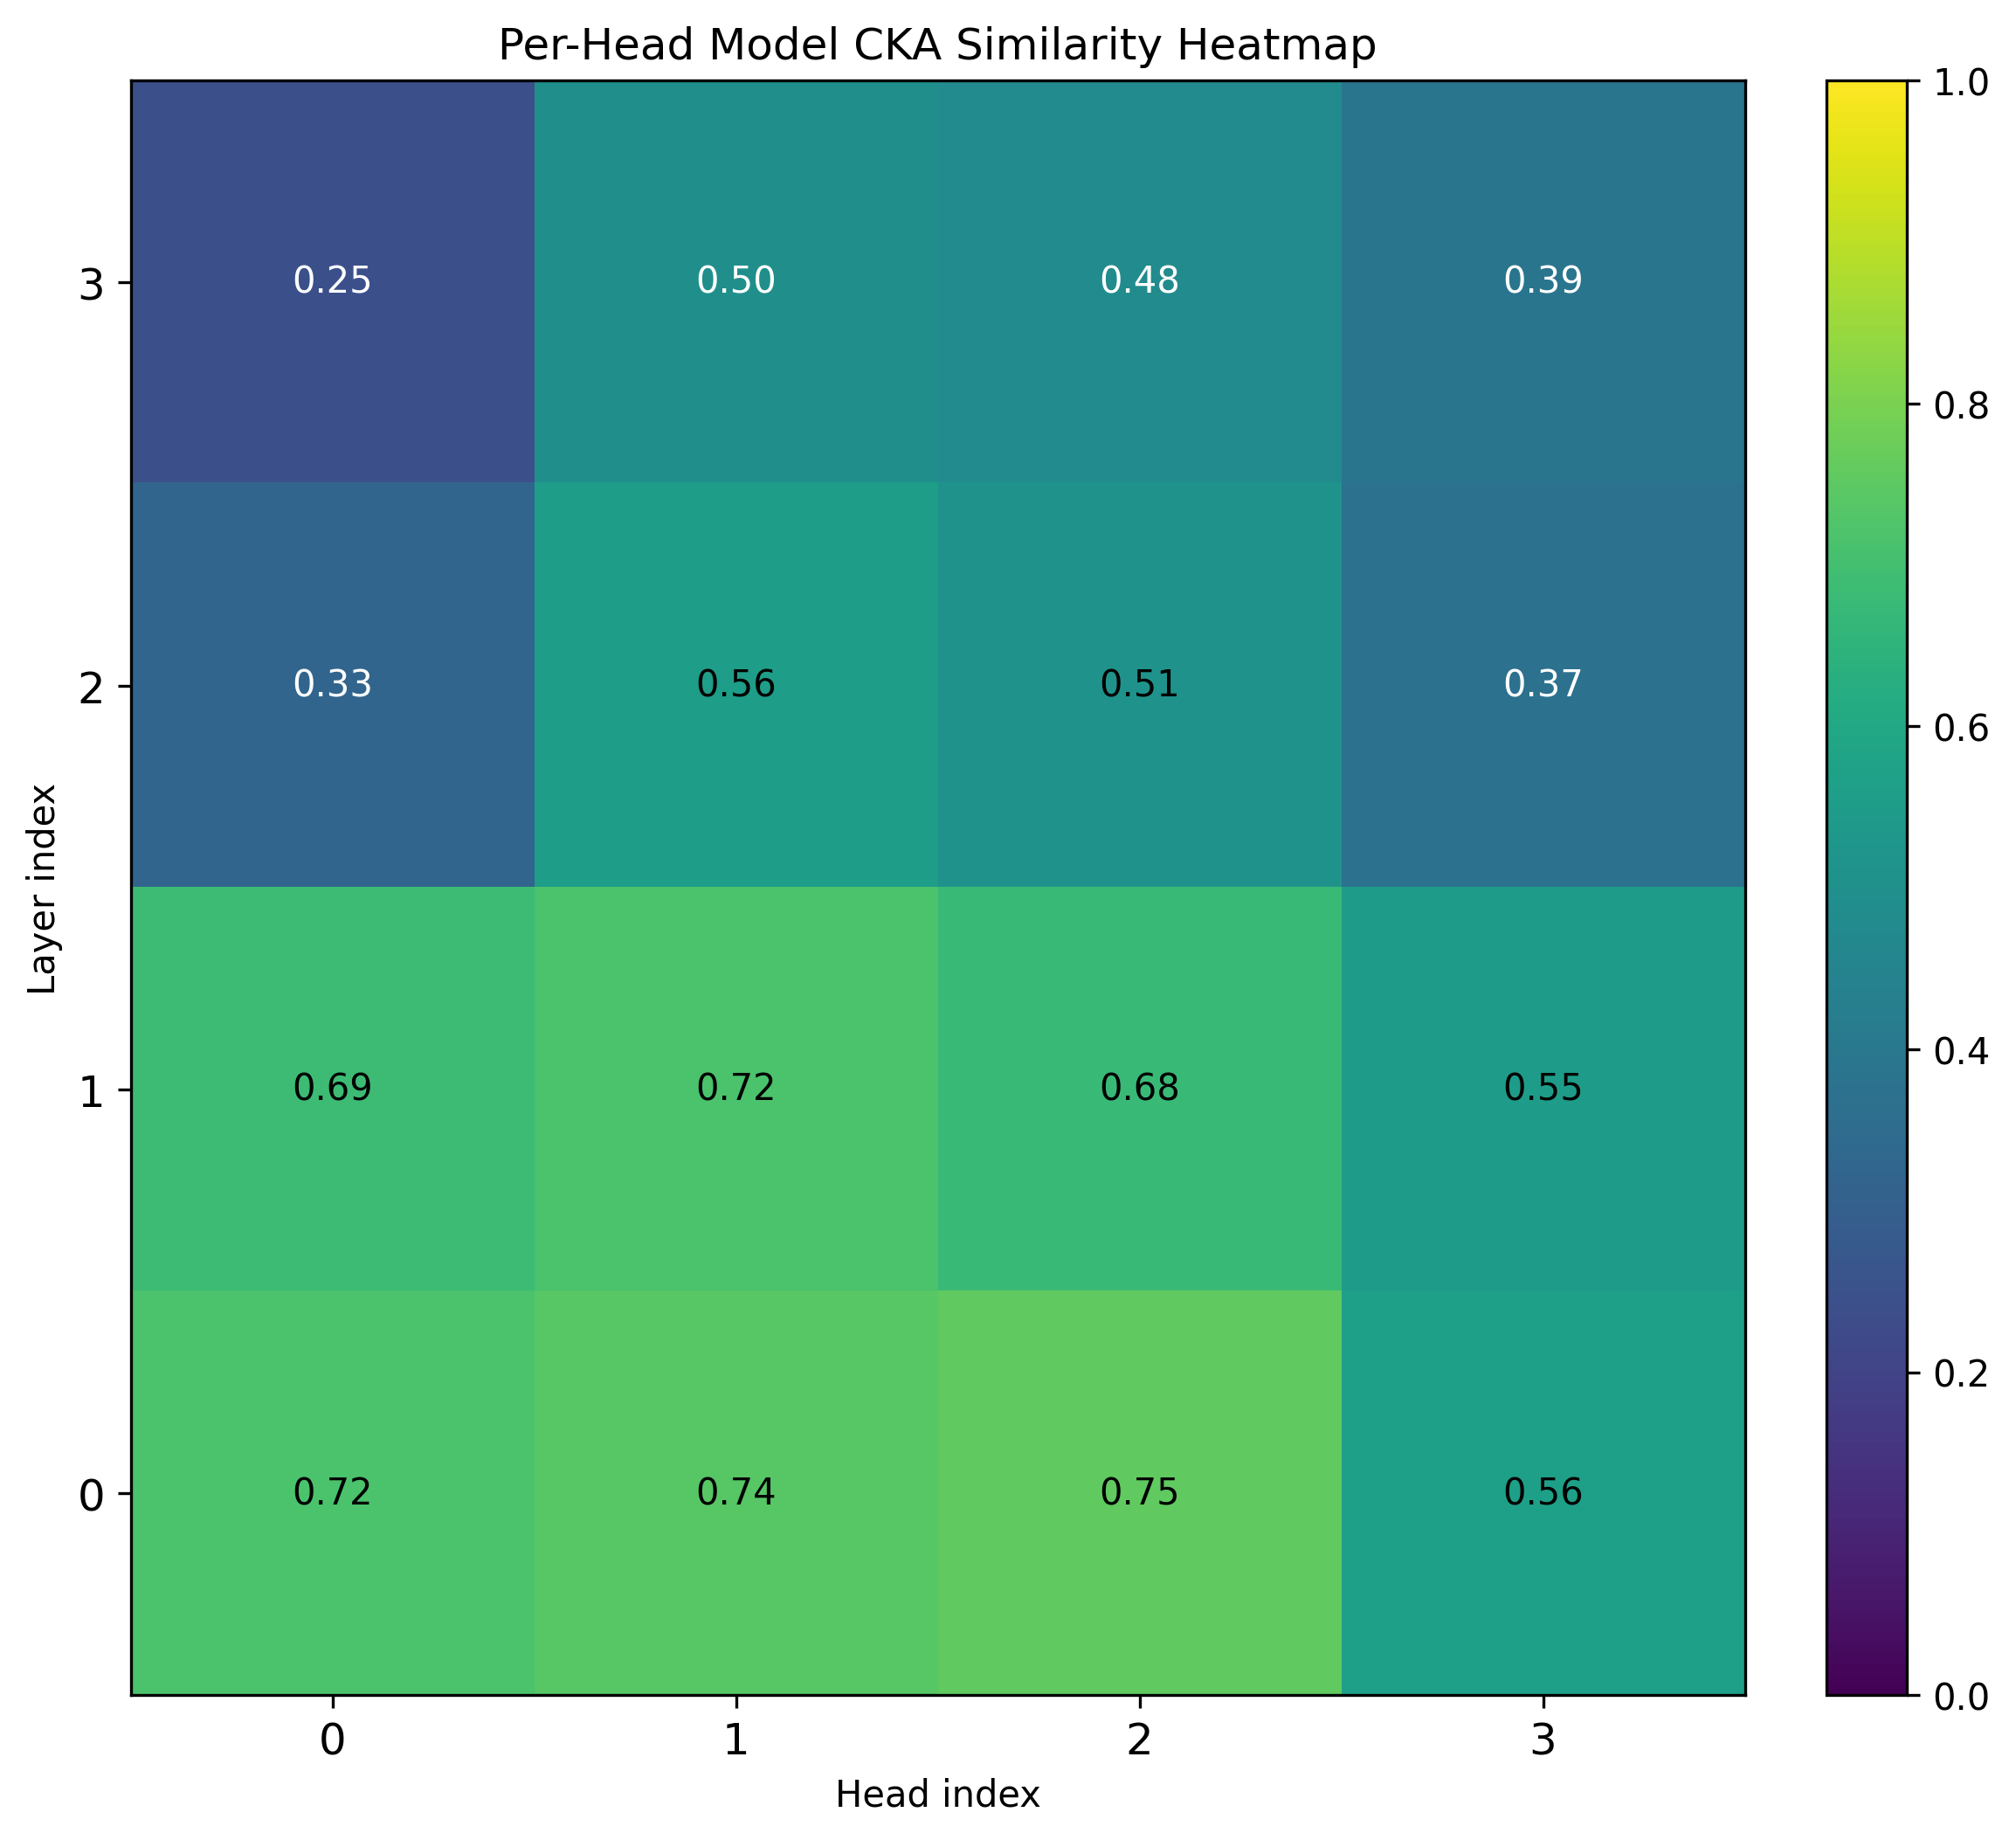

In [20]:
log_per_head_model_heatmap(
    [
        compute_mean_per_head_similarities(
            compute_pairwise_symmetric_similarity_matrix(attn_weights, metric_fn=cka)
        )
        for attn_weights in attn_weights_list[2]
    ],
)

In [34]:
model, _ = load_checkpoint("out-124M-causal", 2000, True)
X, Y = get_batch("val", 16, model_cfg.block_size)
_, _, attn_weights = model(X, Y, output_attentions=True)

number of parameters: 123.59M


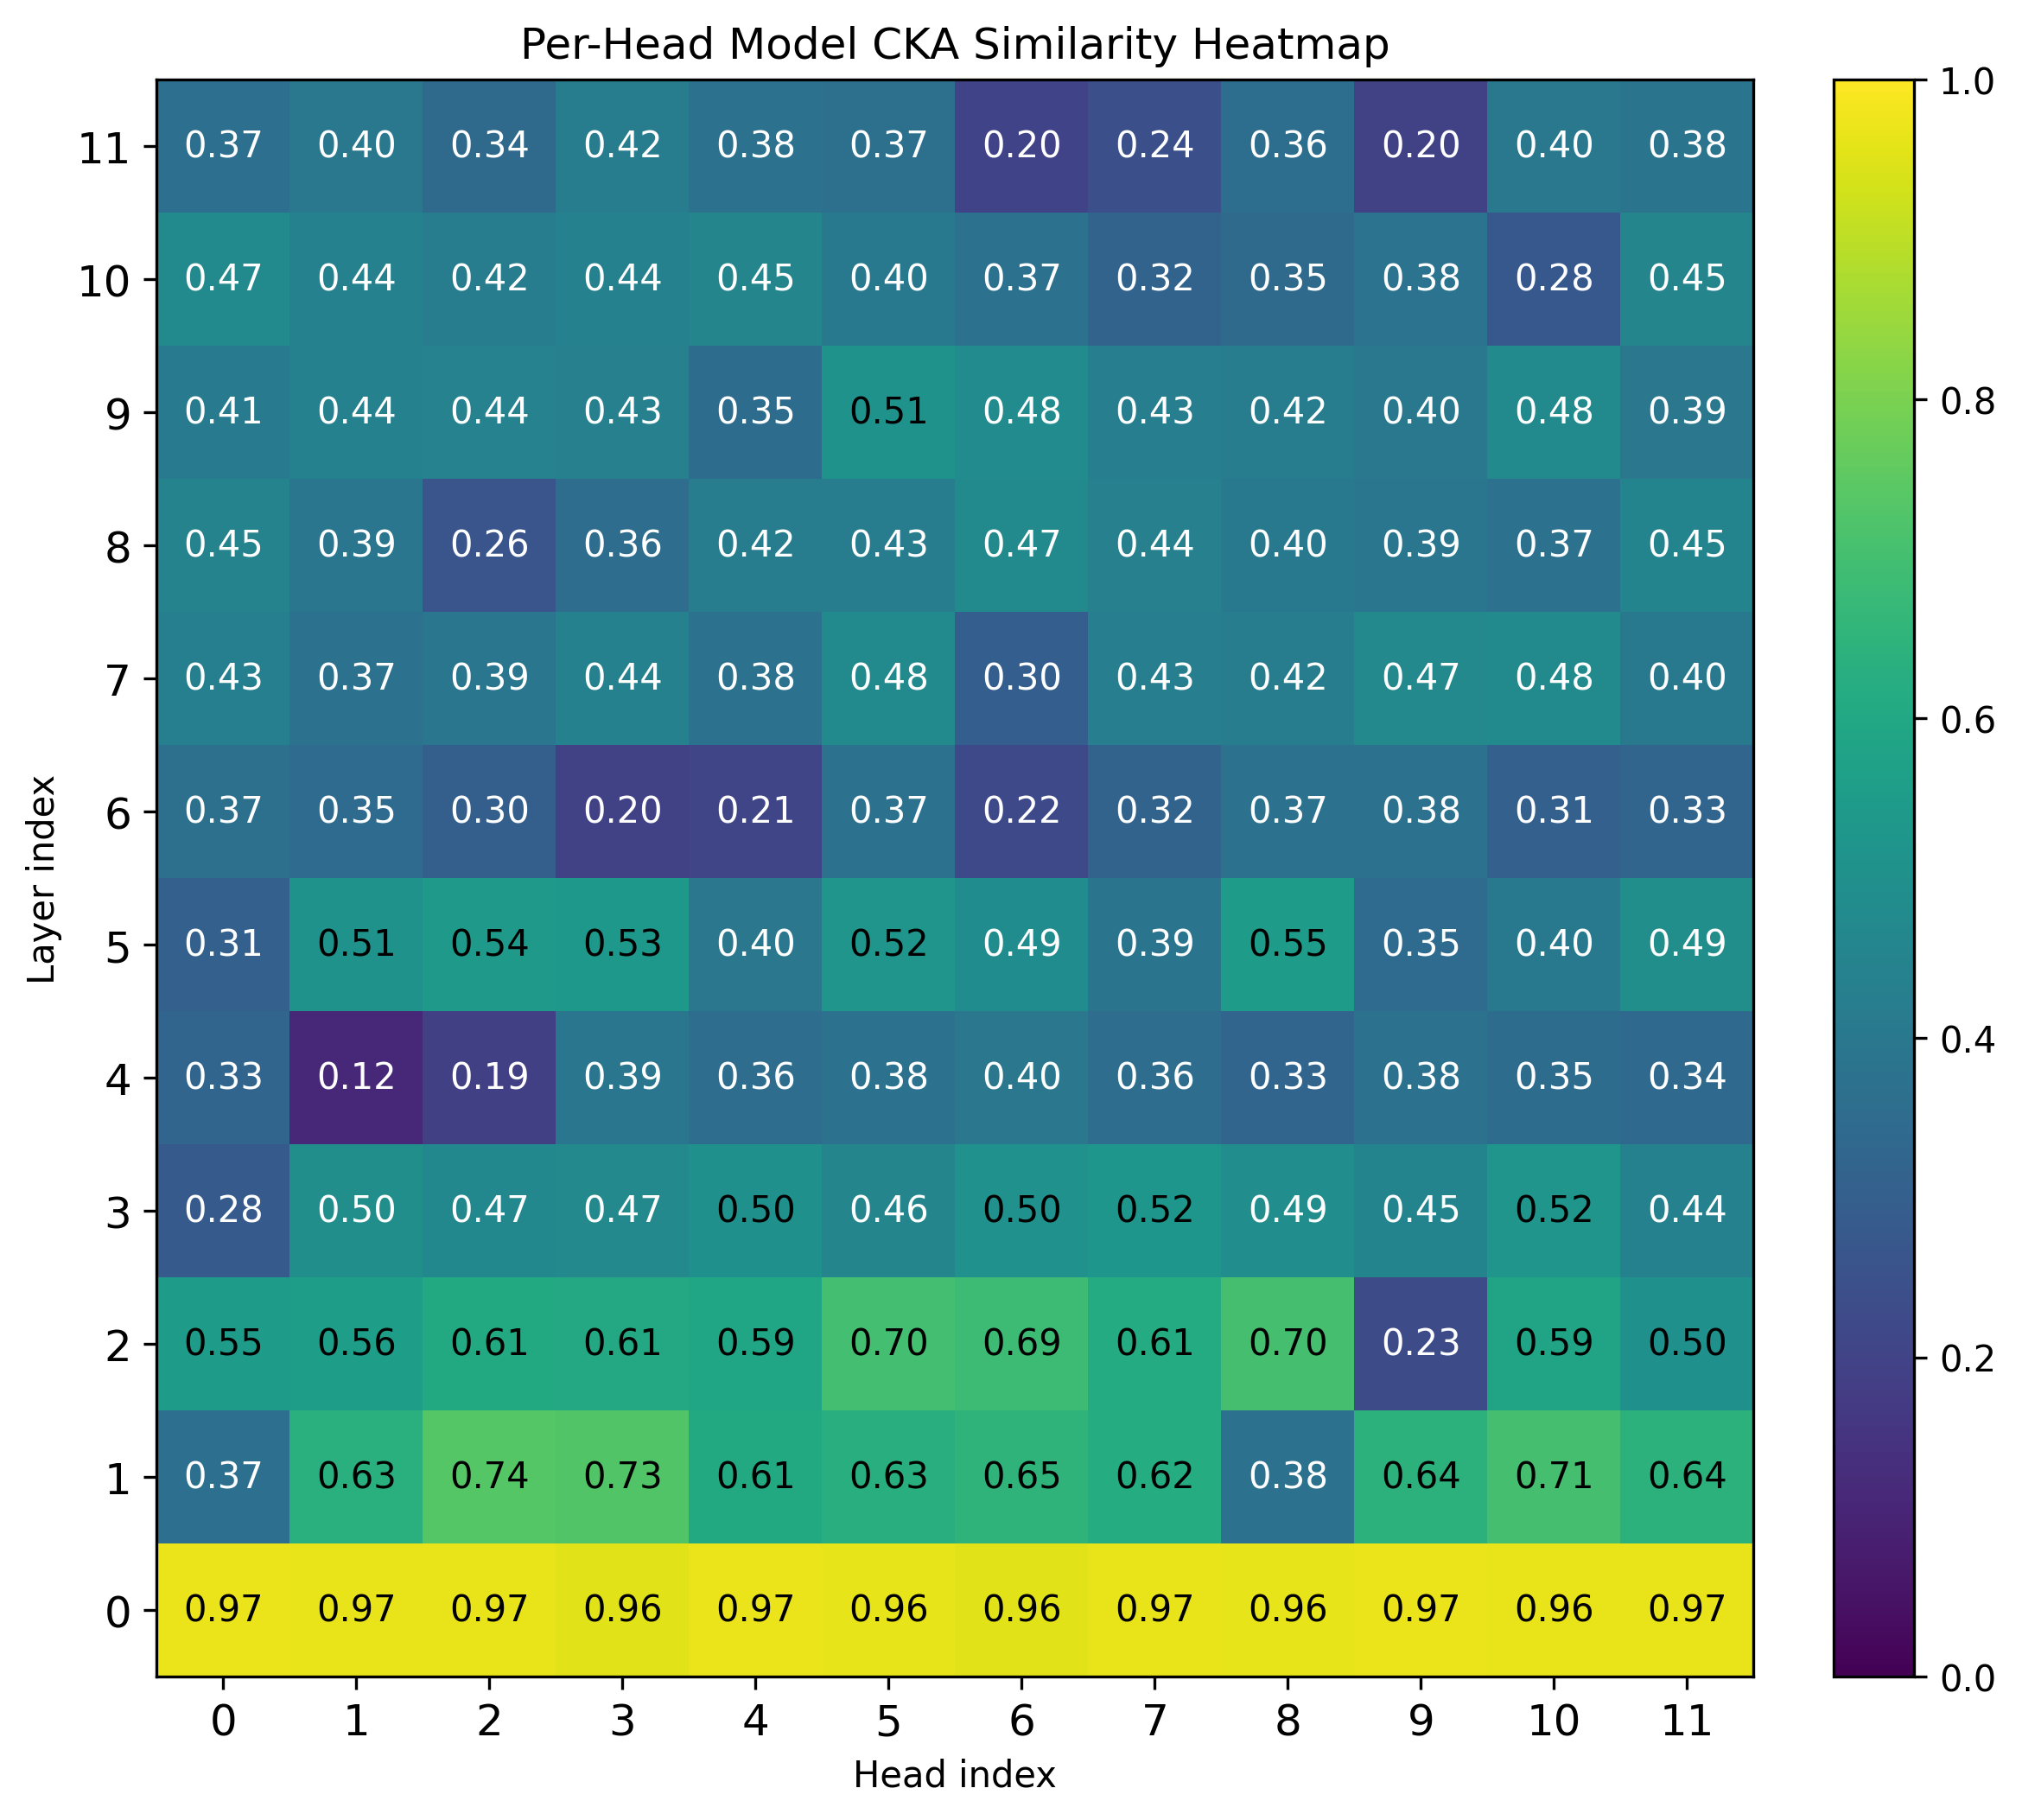

In [35]:
log_per_head_model_heatmap(
    [
        compute_mean_per_head_similarities(
            compute_pairwise_symmetric_similarity_matrix(attn_weights, metric_fn=cka)
        )
        for attn_weights in attn_weights
    ]
)